# 05 — PCA Exploration

Unsupervised experiment: use **Principal Component Analysis** to understand which numerical features drive the most variance in the HDB dataset, and visualise how flats cluster in 2D.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
train = pd.read_csv('../../data/raw/train.csv')
print(f'Shape: {train.shape}')
train.head(3)

Shape: (150634, 77)


/var/folders/yb/1npjbkhd2mqg3r6dqz0396sh0000gn/T/ipykernel_53475/3500419198.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../../data/raw/train.csv')


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,...,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,...,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,...,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013


## 1  Select numerical features

PCA only works on **numbers**. We keep all numerical columns, drop the target (`resale_price`) and obvious ID/date columns that aren't meaningful as magnitudes.

In [3]:
DROP = ['id','resale_price','Tranc_YearMonth']

num_cols = [c for c in train.select_dtypes(include='number').columns
            if c not in DROP]

print(f'{len(num_cols)} numerical features used:')
print(num_cols)

55 numerical features used:
['floor_area_sqm', 'lease_commence_date', 'Tranc_Year', 'Tranc_Month', 'mid_storey', 'lower', 'upper', 'mid', 'floor_area_sqft', 'hdb_age', 'max_floor_lvl', 'year_completed', 'total_dwelling_units', '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'Latitude', 'Longitude', 'Mall_Nearest_Distance', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Nearest_Distance', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'mrt_nearest_distance', 'bus_interchange', 'mrt_interchange', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance', 'vacancy', 'pri_sch_affiliation', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist', 'cutoff_point', 'affiliation', 'sec_sch_

## 2  Impute & scale

PCA cannot handle NaN values. We fill missing values with the **median** of each column, then **standardise** (mean=0, std=1) so no single large-scale feature dominates.

In [4]:
X_raw = train[num_cols].copy()

imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(X_raw)

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'Ready: {X_scaled.shape[0]:,} rows × {X_scaled.shape[1]} features')

Ready: 150,634 rows × 55 features


## 3  Scree plot — how many PCs matter?

A **scree plot** shows how much of the total variance each principal component captures.  
- If 2–3 PCs already capture 70%+ of variance → the data has low intrinsic dimensionality.  
- If you need 20+ PCs → data is genuinely high-dimensional.

PCs needed for 80% variance: 22
PCs needed for 90% variance: 28
PCs needed for 95% variance: 33


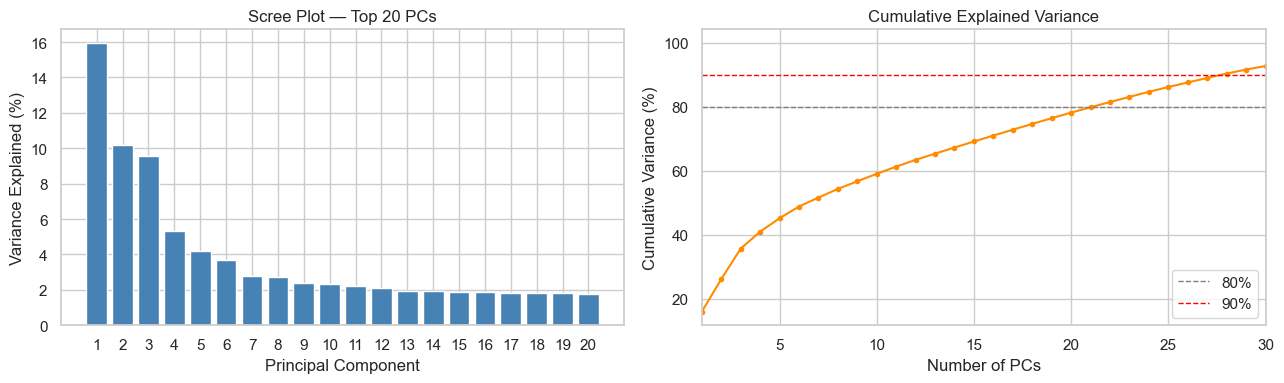

Saved: outputs/figures/pca_scree.png


In [5]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained       = pca_full.explained_variance_ratio_
cumulative      = np.cumsum(explained)

# How many PCs to reach 80%, 90%, 95%
for threshold in [0.80, 0.90, 0.95]:
    n = np.searchsorted(cumulative, threshold) + 1
    print(f'PCs needed for {threshold:.0%} variance: {n}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree (individual)
axes[0].bar(range(1, 21), explained[:20] * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — Top 20 PCs')
axes[0].set_xticks(range(1, 21))

# Cumulative
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker='.', color='darkorange')
axes[1].axhline(80, ls='--', color='gray', lw=1, label='80%')
axes[1].axhline(90, ls='--', color='red',  lw=1, label='90%')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_xlim(1, 30)

plt.tight_layout()
plt.savefig('../../outputs/figures/pca_scree.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pca_scree.png')

## 4  2D scatter — PC1 vs PC2

Project every flat onto the first **two** principal components and colour each dot by `resale_price`.  
This is the highest-variance 2D "view" of the data — similar flats should cluster together.

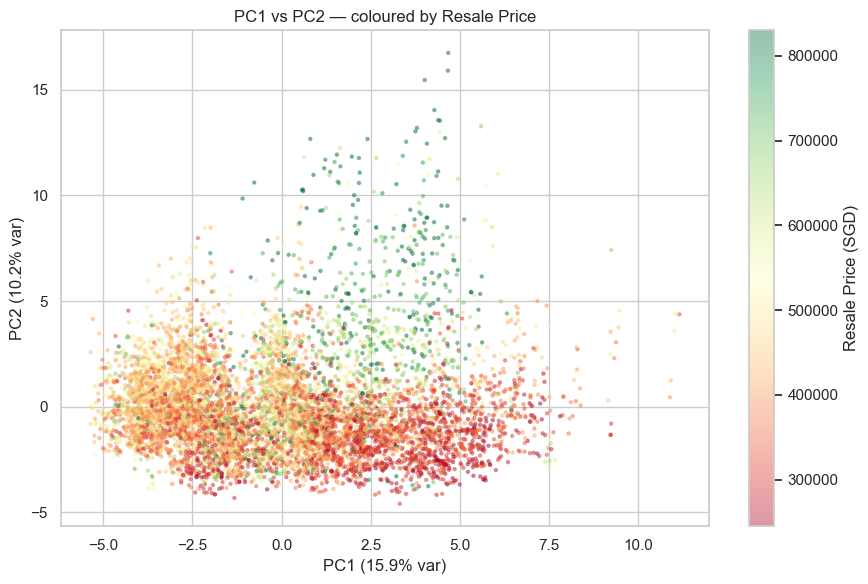

Saved: outputs/figures/pca_2d_price.png


In [6]:
pca2 = PCA(n_components=2, random_state=42)
Z    = pca2.fit_transform(X_scaled)

sample_idx = np.random.default_rng(42).choice(len(Z), size=min(8000, len(Z)), replace=False)
Zs   = Z[sample_idx]
ys   = train['resale_price'].iloc[sample_idx].values
ts   = train['town'].iloc[sample_idx].values

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(Zs[:, 0], Zs[:, 1],
                c=ys, cmap='RdYlGn', alpha=0.4, s=5,
                vmin=np.percentile(ys, 2), vmax=np.percentile(ys, 98))
plt.colorbar(sc, ax=ax, label='Resale Price (SGD)')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PC1 vs PC2 — coloured by Resale Price')
plt.tight_layout()
plt.savefig('../../outputs/figures/pca_2d_price.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pca_2d_price.png')

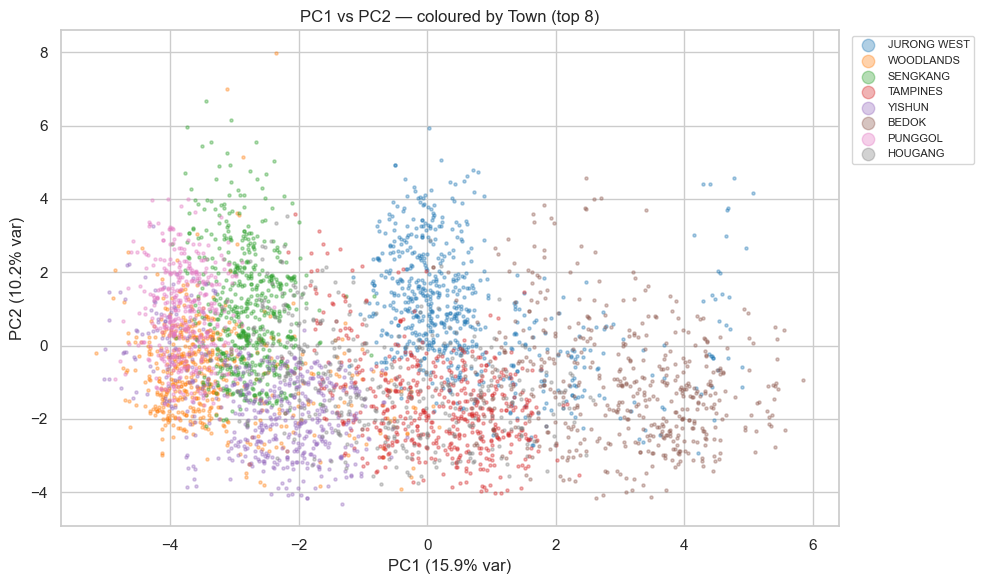

Saved: outputs/figures/pca_2d_town.png


In [7]:
top_towns = train['town'].value_counts().head(8).index.tolist()
palette   = sns.color_palette('tab10', len(top_towns))
town_color = {t: palette[i] for i, t in enumerate(top_towns)}

fig, ax = plt.subplots(figsize=(10, 6))
for town, grp_idx in [(t, np.where(ts == t)[0]) for t in top_towns]:
    ax.scatter(Zs[grp_idx, 0], Zs[grp_idx, 1],
               color=town_color[town], alpha=0.35, s=5, label=town)
ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('PC1 vs PC2 — coloured by Town (top 8)')
plt.tight_layout()
plt.savefig('../../outputs/figures/pca_2d_town.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pca_2d_town.png')

## 5  Feature loadings — what drives PC1 & PC2?

Each PC is a **weighted sum** of the original features.  
The **loading** tells you how much each original feature contributes to that PC.  
- Large positive loading → feature moves in the same direction as the PC  
- Large negative loading → feature moves in the opposite direction

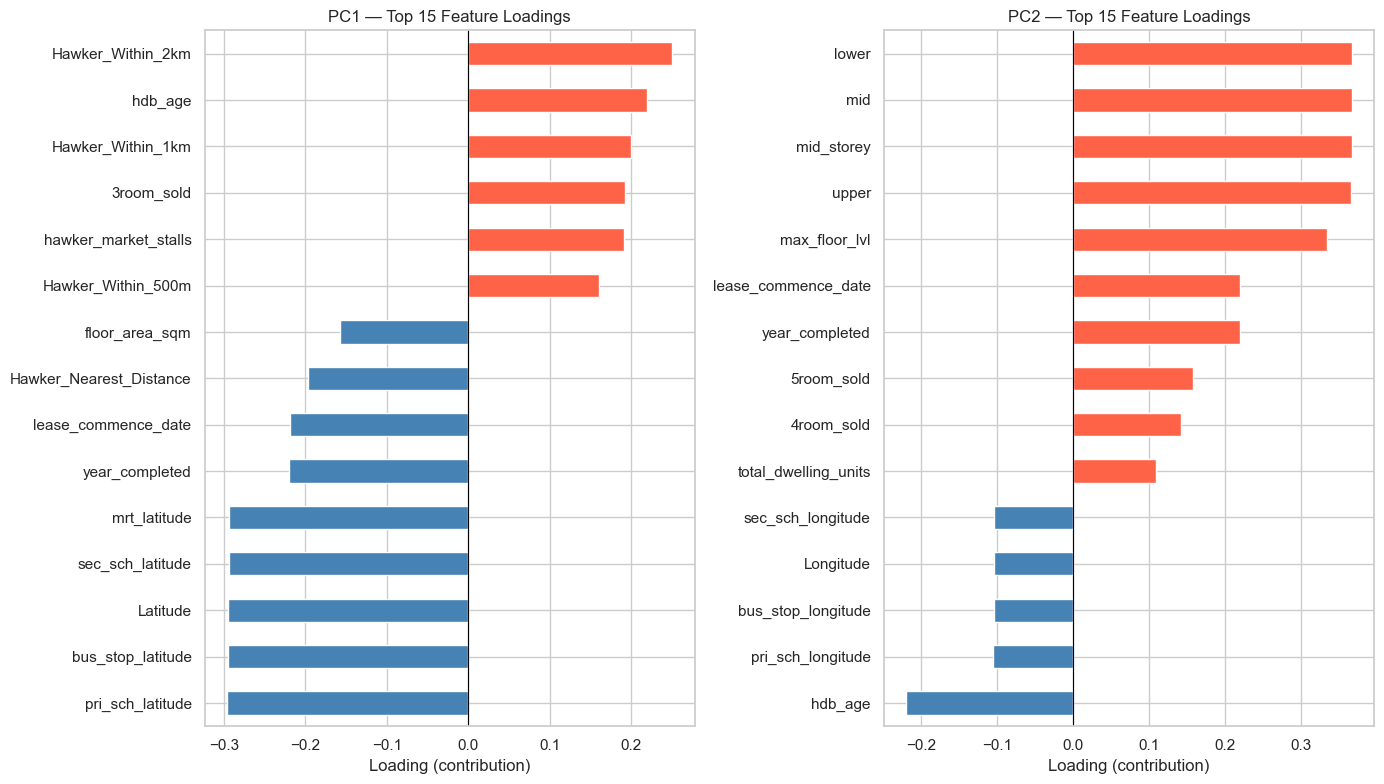

Saved: outputs/figures/pca_loadings.png


In [8]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=num_cols,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    top = loadings[pc].abs().nlargest(15).index
    vals = loadings.loc[top, pc].sort_values()
    colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{pc} — Top 15 Feature Loadings')
    ax.set_xlabel('Loading (contribution)')

plt.tight_layout()
plt.savefig('../../outputs/figures/pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pca_loadings.png')

## 6  Interpretation summary

| | What it means |
|---|---|
| **Scree plot** | See how many PCs you need. If first 2-3 PCs grab 80%+ variance, the dataset is relatively "simple". |
| **2D price plot** | A smooth gradient (green→red left→right or bottom→top) means PC1/PC2 is a good proxy for price. |
| **2D town plot** | If towns form distinct clusters, location is a major source of variation. |
| **Loadings** | Large floor_area_sqm loading confirms our EDA: size is the dominant driver. MRT/Hawker distance loadings reveal the amenity dimension. |

### Limitations
- PCA only uses **numerical** columns. Town, flat_type etc. are excluded.
- PCA finds directions of maximum **variance**, not maximum **price prediction**. A feature can have low loading but still be predictive.
- PCA is exploratory here — we're not using it to reduce features for the model yet.

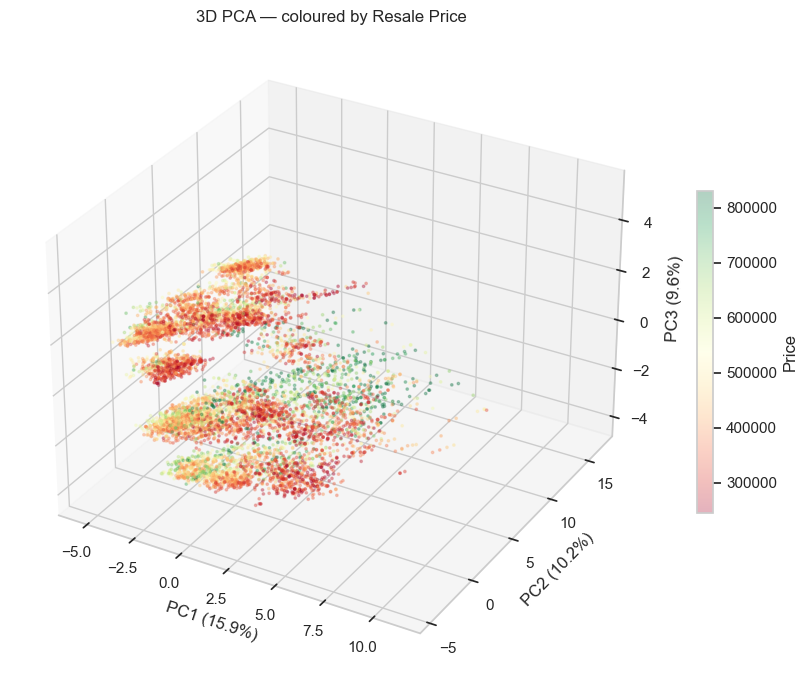

Saved: outputs/figures/pca_3d.png

PC1+PC2+PC3 combined: 35.6% of total variance


In [9]:
# Optional: 3D view
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
Z3   = pca3.fit_transform(X_scaled)
Zs3  = Z3[sample_idx]

fig  = plt.figure(figsize=(9, 7))
ax3d = fig.add_subplot(111, projection='3d')
sc3  = ax3d.scatter(Zs3[:,0], Zs3[:,1], Zs3[:,2],
                    c=ys, cmap='RdYlGn', alpha=0.3, s=3,
                    vmin=np.percentile(ys, 2), vmax=np.percentile(ys, 98))
plt.colorbar(sc3, ax=ax3d, label='Price', shrink=0.5)
ax3d.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]:.1%})')
ax3d.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]:.1%})')
ax3d.set_zlabel(f'PC3 ({pca3.explained_variance_ratio_[2]:.1%})')
ax3d.set_title('3D PCA — coloured by Resale Price')
plt.tight_layout()
plt.savefig('../../outputs/figures/pca_3d.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/pca_3d.png')
print(f'\nPC1+PC2+PC3 combined: {sum(pca3.explained_variance_ratio_):.1%} of total variance')